**Scenario** 

Saya dikontrak sebagai Data Analyst oleh pemilik Kedai Kopi Aroma Jaya untuk memecah anomali operasional di Cabang Sudirman. Pemilik menemukan kejanggalan: secara visual terjadi antrean pelanggan yang sangat panjang, namun laporan dashboard menunjukkan pendapatan yang stagnan. Di sisi lain, pemilik telah meningkatkan pasokan bahan baku dalam jumlah besar sebagai antisipasi keramaian, yang justru berujung pada kerugian akibat penumpukan stok. Proyek analisis data transaksi Poin of Sales (Januari-Juni 2026) ini bertujuan untuk mengidentifikasi akar masalah antrean, memetakan perilaku pembelian konsumen, serta menyusun rekomendasi strategi optimasi operasional dan efisiensi stok agar kerugian serupa tidak terulang kembali.

**Define Question**

Untuk membantu sang owner, saya memerlukan beberapa informasi yang berhubungan dengan antrian panjang. Sehingga, pertanyaan yang saya definisikan adalah sebagai berikut:
1. Bagaimana tren penjualan Aroma Jaya dari waktu ke waktu?
2. Hari apa saja dalam seminggu yang cenderung paling banyak penjualan?
3. Waktu/jam berapa saja yang cenderung paling banyak penjualan?

let's dive in!

### Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# mengatur tampilan grafik
sns.set_theme(
    # warna putih warna yang paling bersih
    style="white", 
    rc={
        # membuat kotak pembungkus grafik hilang
        "axes.spines.top": False,
        "axes.spines.bottom": False,
        "axes.spines.right": False,
        "axes.spines.left": False,

        # mengatur agar warna labelnya abu abu, 
        # dan jarak label dengan ticksnya
        "axes.labelcolor": "grey",
        "xtick.color": "grey",
        "ytick.color": "grey",
        "axes.labelpad": 10,

        # mengatur warna, posisi, jarak, dan ukuran judul grafiknya
        "axes.titlecolor": "black", 
        "axes.titlelocation": "left", 
        "axes.titlepad": 15,            
        "axes.titlesize": 15
    }
)

### Load & filter data

In [2]:
# load data yang sudah dibersihkan pada tahap prepartion data 
data = pd.read_csv('cleaned_data.csv')
data.head()

,transaction_id,transaction_date,store_location,product_id,product_name,product_category,quantity,unit_price,tipe_order,omzet,month,day,hour
0,TX00001,2026-01-01,Gading Serpong,106,Roti Bakar Bandung,Snack,1,18000,Dine-in,18000,January,Thursday,7
1,TX00002,2026-01-01,Senopati,102,Americano,Coffee,2,25000,Takeaway,50000,January,Thursday,7
2,TX00003,2026-01-01,Sudirman,101,Es Kopi Susu Gula Aren,Coffee,1,22000,Takeaway,22000,January,Thursday,7
3,TX00004,2026-01-01,Gading Serpong,101,Es Kopi Susu Gula Aren,Coffee,1,22000,Dine-in,22000,January,Thursday,7
4,TX00005,2026-01-01,Gading Serpong,101,Es Kopi Susu Gula Aren,Coffee,1,22000,Dine-in,22000,January,Thursday,7


In [3]:
# filter hanya data dari cabang Sudirman
data = data[data['store_location'] == 'Sudirman']
len(data)

19858

### Data info and basic statistics

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19858 entries, 2 to 42582
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    19858 non-null  object
 1   transaction_date  19858 non-null  object
 2   store_location    19858 non-null  object
 3   product_id        19858 non-null  int64 
 4   product_name      19858 non-null  object
 5   product_category  19858 non-null  object
 6   quantity          19858 non-null  int64 
 7   unit_price        19858 non-null  int64 
 8   tipe_order        19858 non-null  object
 9   omzet             19858 non-null  int64 
 10  month             19858 non-null  object
 11  day               19858 non-null  object
 12  hour              19858 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 2.1+ MB


In [5]:
data.describe()

,product_id,quantity,unit_price,omzet,hour
count,19858.000000,19858.000000,19858.000000,19858.000000,19858.000000
mean,103.133397,1.405479,22695.689395,31900.745292,13.729832
std,2.138123,0.821388,5588.984280,20801.197093,4.581974
min,101.000000,1.000000,10000.000000,10000.000000,7.000000
25%,101.000000,1.000000,22000.000000,22000.000000,9.000000
50%,102.000000,1.000000,22000.000000,25000.000000,13.000000
75%,105.000000,2.000000,25000.000000,30000.000000,18.000000
max,108.000000,5.000000,30000.000000,150000.000000,21.000000


In [6]:
data.describe(include='object')

,transaction_id,transaction_date,store_location,product_name,product_category,tipe_order,month,day
count,19858,19858,19858,19858,19858,19858,19858,19858
unique,14387,180,1,8,4,2,6,7
top,TX20678,2026-04-25,Sudirman,Es Kopi Susu Gula Aren,Coffee,Dine-in,May,Saturday
freq,4,204,19858,6241,12766,10214,3533,4414


### 1.Bagaimana tren penjualan Aroma Jaya dari waktu ke waktu?

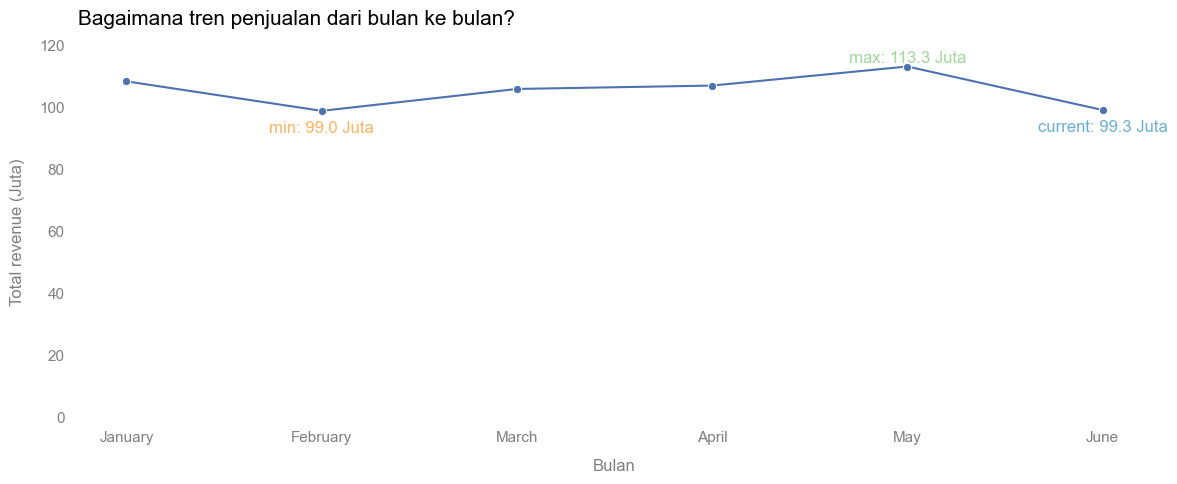

In [27]:
# aggregat total transaksi per bulannya
tren_transaksi = data.groupby('month').agg(
    total_revenue = ('omzet','sum')
).reset_index()

# mengubah angkanya menjadi lebih mudah dibaca
tren_transaksi['total_revenue'] = tren_transaksi['total_revenue']/1000000

# mengurutkan hasilnya berdasarkan urutan nama bulan
ordered_month = ['January','February','March','April','May','June']
tren_transaksi['month'] = pd.Categorical(tren_transaksi['month'], categories=ordered_month, ordered=True)
tren_transaksi = tren_transaksi.sort_values('month').reset_index(drop=True)

# ambil data max, min, dan current
idx_max = tren_transaksi['total_revenue'].idxmax()
idx_min = tren_transaksi['total_revenue'].idxmin()
idx_current = tren_transaksi[tren_transaksi['month'] == 'June' ].index[0]

# membuat grafik lineplot
plt.figure(figsize=(12,5))
ax = sns.lineplot(tren_transaksi, x='month', y='total_revenue', marker='o')

# membuat text di dalam grafik 
# membuat teks jumlah transaksi untuk bulan dengan transaksi paling banyak
row_max = tren_transaksi.iloc[idx_max]
ax.text(
    x = idx_max, 
    y = row_max['total_revenue']+1,
    s = f"max: {row_max['total_revenue']:.1f} Juta", 
    color = '#A1D99B', 
    ha = 'center'
)

# membuat teks jumlah transaksi untuk bulan dengan transaksi paling sedikit
row_min = tren_transaksi.iloc[idx_min]
ax.text(
    x = idx_min, 
    y = row_min['total_revenue']-7,
    s = f"min: {row_min['total_revenue']:.1f} Juta", 
    color = '#FDB462', 
    ha = 'center'
)

# membuat teks jumlah transaksi untuk bulan terbaru
row_current = tren_transaksi.iloc[idx_current]
ax.text(
    x = idx_current, 
    y = row_current['total_revenue']-7,
    s = f"current: {row_current['total_revenue']:.1f} Juta", 
    color = '#6baed6',  
    ha = 'center'
)

# mengatur limit angka sumbu y, untuk menghindari kesalahan interpretasi
ax.set_ylim(bottom=0, top=120)

# mengatur judul, label x, dan label y pada grafik
ax.set_title('Bagaimana tren penjualan dari bulan ke bulan?')
ax.set_xlabel('Bulan')
ax.set_ylabel('Total revenue (Juta)')

plt.tight_layout()
plt.show()

- seperti yang dikatakan oleh sang owner. laporan transaksi per bulannya ternyata memang lumayan datar, malah menurun di bulan terbaru ini
- rentang revenue antara 99 - 113 Juta (selisih 14 Juta-an). Bukan selisih yang begitu besar, mengingat ini adalah perbandingan transaksi dalam perbulan.

Apakah stagnansi ini terjadi karena jumlah pembeli (transaksi) yang sedikit, atau karena rata-rata uang yang dibelanjakan pelanggan (nilai struk) terlalu kecil? mari kita selami lebih dalam

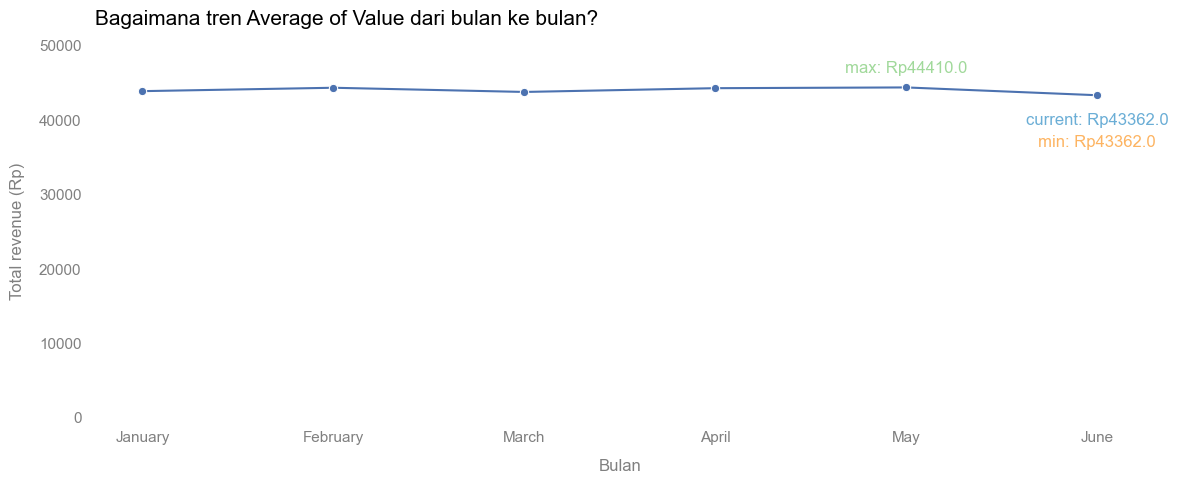

In [25]:
# menghitung rata-rata nilai transaksi (AOV) per bulan
# grouby month dan transaction_id untuk menggabungkan item yang punya transaction_id yang sama
month_transaction = data.groupby(['month','transaction_id']).agg(
    total_revenue = ('omzet','sum')
).reset_index()

tren_aov = month_transaction.groupby('month').agg(
    aov = ('total_revenue', 'mean')
).reset_index()

# menghilangkan angka belakang koma
tren_aov['aov'] = tren_aov['aov'].round(0)

# mengurutkan hasilnya berdasarkan urutan nama bulan
ordered_month = ['January','February','March','April','May','June']
tren_aov['month'] = pd.Categorical(tren_aov['month'], categories=ordered_month, ordered=True)
tren_aov = tren_aov.sort_values('month').reset_index(drop=True)

# ambil data max, min, dan current
idx_max = tren_aov['aov'].idxmax()
idx_min = tren_aov['aov'].idxmin()
idx_current = tren_aov[tren_aov['month'] == 'June' ].index[0]

# membuat grafik lineplot
plt.figure(figsize=(12,5))
ax = sns.lineplot(tren_aov, x='month', y='aov', marker='o')

# membuat text di dalam grafik 
# membuat teks jumlah transaksi untuk bulan dengan transaksi paling banyak
row_max = tren_aov.iloc[idx_max]
ax.text(
    x = idx_max, 
    y = row_max['aov']+2000,
    s = f"max: Rp{row_max['aov']}", 
    color = '#A1D99B', 
    ha = 'center'
)

# membuat teks jumlah transaksi untuk bulan dengan transaksi paling sedikit
row_min = tren_aov.iloc[idx_min]
ax.text(
    x = idx_min, 
    y = row_min['aov']-7000,
    s = f"min: Rp{row_min['aov']}", 
    color = '#FDB462', 
    ha = 'center'
)

# membuat teks jumlah transaksi untuk bulan terbaru
row_current = tren_aov.iloc[idx_current]
ax.text(
    x = idx_current, 
    y = row_current['aov']-4000,
    s = f"current: Rp{row_current['aov']}", 
    color = '#6baed6',  
    ha = 'center'
)

# mengatur limit angka sumbu y, untuk menghindari kesalahan interpretasi
ax.set_ylim(bottom=0, top=50000)

# mengatur judul, label x, dan label y pada grafik
ax.set_title('Bagaimana tren Average of Value dari bulan ke bulan?')
ax.set_xlabel('Bulan')
ax.set_ylabel('Total revenue (Rp)')

plt.tight_layout()
plt.show()

In [26]:
tren_aov

,month,aov
0,January,43911.0
1,February,44367.0
2,March,43803.0
3,April,44309.0
4,May,44410.0
5,June,43362.0


- Selisih antara titik terendah (Februari: ~Rp43.300) dan titik tertinggi (April: ~Rp44.400) hanya sekitar Rp1.100 saja
- Artinya nominal belanja pelanggan per struk selama 6 bulan terakhir sebenarnya tidak berubah secara signifikan (sangat stabil).
- Mayoritas konsumen yang datang ke Aroma Jaya cabang Sudirman dari bulan Januari hingga Juni secara konsisten hanya membeli 1-2 item per transaksi.
- Stagnasi omzet bulanan Aroma Jaya bukan disebabkan oleh perubahan daya beli konsumen yang tiba-tiba mendadak hemat, melainkan karena nilai keranjang belanja pelanggan yang memang sangat kecil dan tidak berhasil dinaikkan oleh kedai selama 6 bulan terakhir. Kasir sibuk mengantre panjang karena melayani ribuan transaksi kecil yang nilainya seragam (Rp43.000-an).

hal ini sesuai dengan statistik yang ditunjukan dibagian atas sebelumnya. bahwa 50% dari seluruh penjualan per transaksi itu hanyalah 1 item dan 75% dari penjualan per transaksi adalah 2 item. Namun, untuk lebih jelas, mari kita buat dalam bentuk histogram

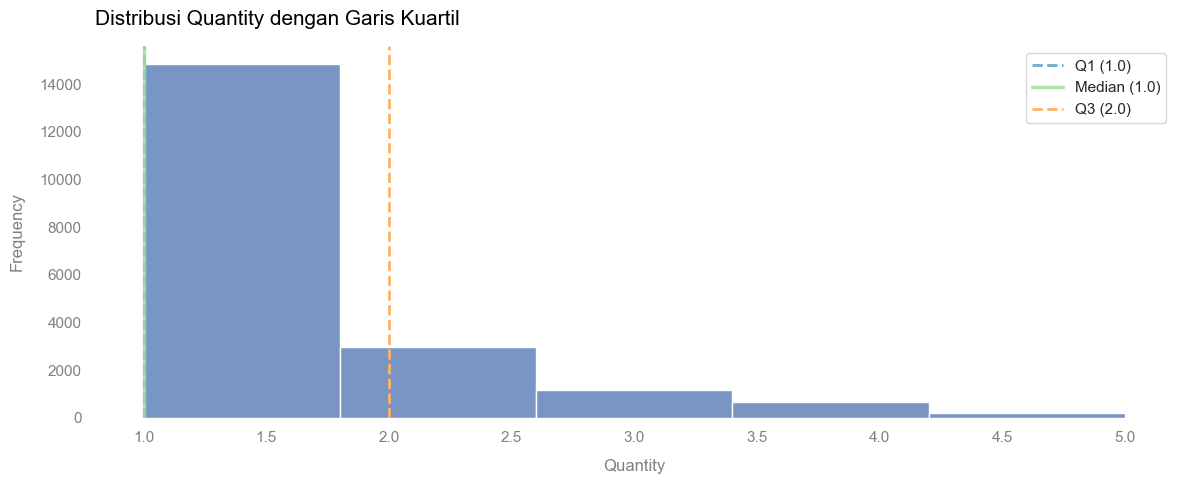

In [10]:
# hitung nilai Q1, Median, dan Q3 dari kolom quantity
q1 = data['quantity'].quantile(0.25)
median = data['quantity'].median()
q3 = data['quantity'].quantile(0.75)

plt.figure(figsize=(12, 5))
ax = sns.histplot(data=data, x='quantity', bins=5)

# menambahkan garis untuk kuartil
# q1
ax.axvline(x=q1, color='#6baed6', linestyle='--', linewidth=2, label=f'Q1 ({q1:.1f})')

# median
ax.axvline(x=median, color='#A1D99B', linestyle='-', linewidth=2.5, alpha=0.8, label=f'Median ({median:.1f})')

# q3
ax.axvline(x=q3, color='#FDB462', linestyle='--', linewidth=2, label=f'Q3 ({q3:.1f})')

ax.set_title('Distribusi Quantity dengan Garis Kuartil')
ax.set_xlabel('Quantity')
ax.set_ylabel('Frequency')

plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

- seperti yang dapat dilihat dari grafik histogram ini. Q3 atau 75% dari keseluruhan data terletak di tepi sebelah kiri batang ke 2. artinya 75% transaksi mayoritas hanya membeli 1 item dan sedikit yang 2 item. 

### 2.Hari apa saja dalam seminggu yang cenderung paling banyak penjualan?

Setelah mengetahui bagaimana tren pendapatan perbulan, mari kita cek dalam dimensi yang lebih dalam, yaitu perhari. Tujuannya untuk mengetahui apakah dari pendapatan tersebut disumbang oleh beberapa hari yang penjualannya sangat tinggi daripada hari yang lain? atau semuanya merata perharinya? Analisis ini juga akan menjadi pondasi dalam menentukan rekomendasi terkait optimasi operasional kedai, terutama jika ditemukan ada hari-hari yang lebih sibuk daripada hari lainnya

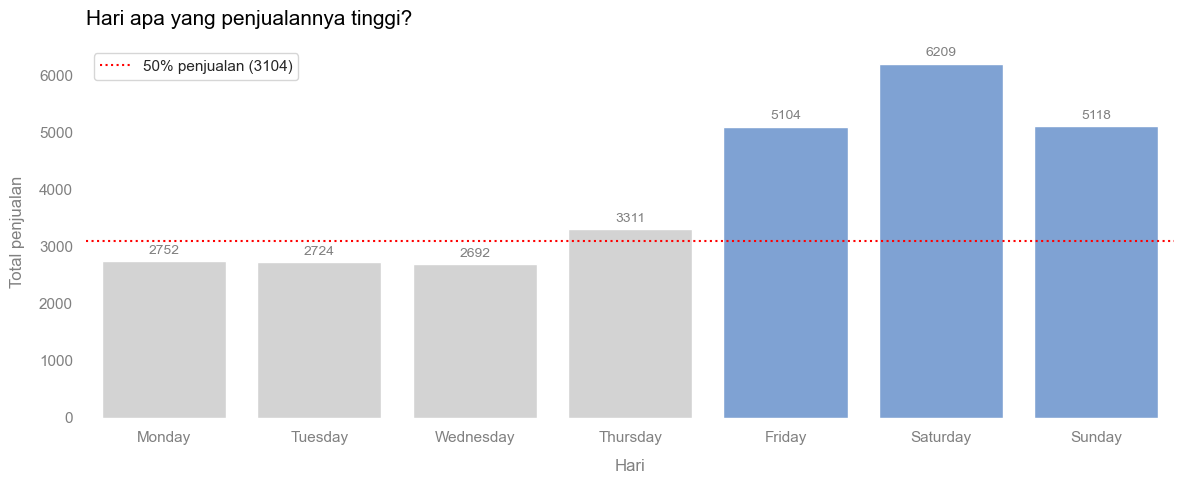

In [11]:
# membuat list untuk mengurutkan hari
urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# groupby total transkasi
# berdasarkan hari dalam seminggu
group = data.groupby('day').agg(
    orders = ('quantity','sum')
).reset_index()

#urutkan nama hari
group['day'] = pd.Categorical(group['day'], categories=urutan_hari, ordered=True)
group = group.sort_values('day')

# hari yang masuk top_3 diberi warna biru
top_3_days = group.nlargest(3, 'orders')['day'].tolist()
warna_palette = {hari: '#71a0e1' if hari in top_3_days else 'lightgrey' for hari in group['day']}

# membuat lineplot untuk transaksi bulan januari
plt.figure(figsize=(12,5))
ax = sns.barplot(group, x='day', y='orders', hue='day', palette=warna_palette, legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=3, color='grey', fontsize=10)

nilai_maksimum = group['orders'].max()
nilai_50_persen = nilai_maksimum * 0.5
ax.axhline(
    y = nilai_50_persen, 
    color = 'red',         
    linestyle = ':',        
    linewidth = 1.5, 
    label = f'50% penjualan ({nilai_50_persen:.0f})'
)

ax.set_title('Hari apa yang penjualannya tinggi?')
ax.set_xlabel('Hari')
ax.set_ylabel('Total penjualan')

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

- Berdasarkan hasil barplot diatas, Top 3 hari yang paling banyak penjualan adalah hari Jumat, Sabtu, dan Minggu dengan ~5.100-6.200 item terjual. Sedangkan hari lainnya hanya ~2.600-3.300 item terjual.
- Hari Jumat, Sabtu dan Minggu diatas 50% dari keseluruhan penjualan, sedangkan hari senin-rabu dibawah 50% penjualan, dan hari kamis hanya sedikit diatas 50% penjualan. Yang artinya perbandingan antara dua kelompok hari ini adalah 2x lipat

Mari kita selami lebih dalam. Apakah pola ini terjadi setiap bulan? atau ada lonjakan di satu bulan tertentu yang menyebabkan hari jumat, sabtu, dan minggu lebih banyak penjualan daripada hari yang lain?

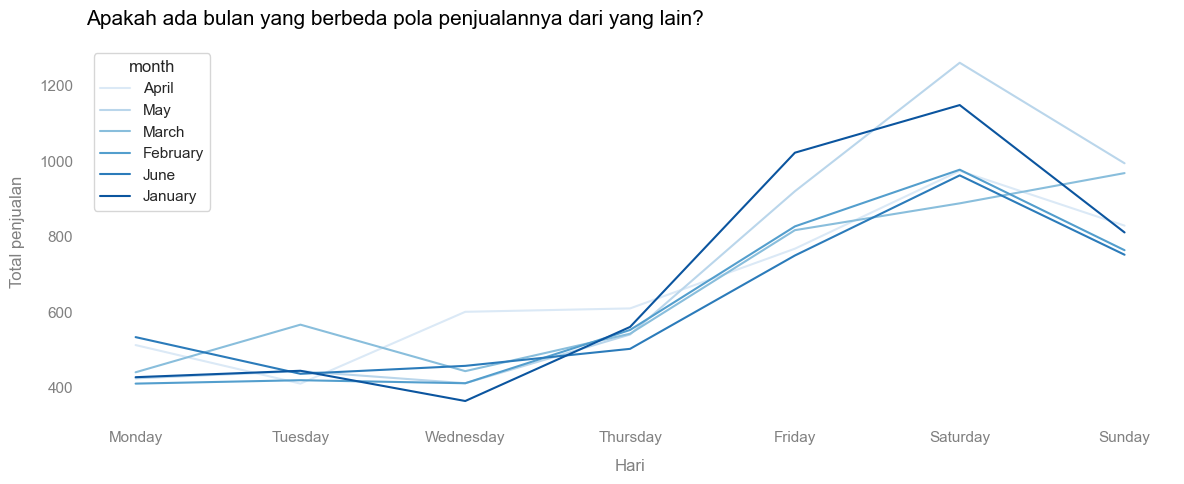

In [12]:
# membuat list untuk mengurutkan hari
urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# groupby total transkasi
# berdasarkan hari dalam seminggu
group = data.groupby(['month','day']).agg(
    orders = ('quantity','sum')
).reset_index()

#urutkan nama hari
group['day'] = pd.Categorical(group['day'], categories=urutan_hari, ordered=True)
group = group.sort_values('day')

# membuat lineplot untuk transaksi bulan januari
plt.figure(figsize=(12,5))
ax = sns.lineplot(group, x='day', y='orders', hue='month', palette='Blues', legend=True)
ax.set_title('Apakah ada bulan yang berbeda pola penjualannya dari yang lain?')
ax.set_xlabel('Hari')
ax.set_ylabel('Total penjualan')

plt.tight_layout()
plt.show()

- Grafik tersebut juga menunjukkan bahwa tidak ada bulan yang memiliki pola yang berbeda dengan bulan yang lain. Sehingga kita dapat dengan pasti membedakan hari-hari tersebut menjadi 2 kategori hari:
  1. Senin-Kamis (normal)
  2. Jumat-Minggu (2x lipat)

### 3.Waktu/jam berapa saja yang cenderung paling banyak penjualan?

Setelah mengetahui hari-hari apa saja yang paling sibuk dan yang tidak sibuk. Saatnya kita menyelam lebih dalam lagi. Kali ini, kita akan memecah hari-hari tersebut menjadi jam dari kedai ini buka sampai tutup. Tujuannya untuk mengetahui dari hari dalam seminggu jam berapa saja yang paling banyak penjualan dan kemungkinan akan sangat sibuk. Sehingga hasil analisis ini nanti akan membuat kita lebih memahami kedai kopi di cabang ini dan menentukan solusi yang tepat.

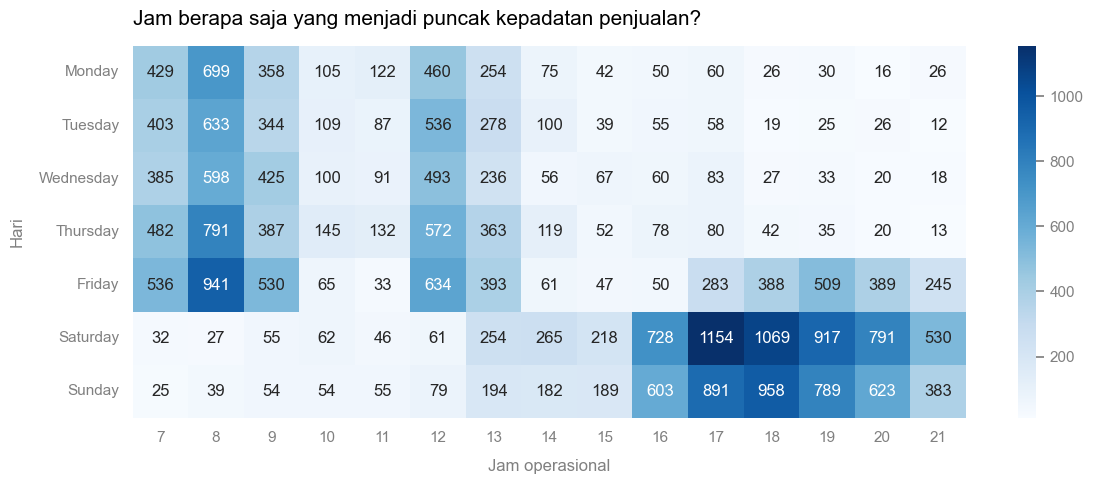

In [13]:
# menggunakan heatmap karena ada 3 kolom (day, hour, total_transaksi)
# pivot tabel untuk mendapatkan total penjualan per hari per jam
urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot_waktu = data.pivot_table(
    index='day',
    columns='hour',
    values='quantity',
    aggfunc='sum'
).reindex(index=urutan_hari) # mengurutkan index hari agar sesusai urutan hari

# membuat heatmap
plt.figure(figsize=(12,5))
ax = sns.heatmap(pivot_waktu, cmap='Blues', annot=True, fmt='g')
ax.set_title('Jam berapa saja yang menjadi puncak kepadatan penjualan?')
ax.set_xlabel('Jam operasional')
ax.set_ylabel('Hari')

plt.tight_layout()
plt.show()

- Terdapat pola berulang yang terjadi per jamnya, dimana:
- Hari Senin-Jumat pukul 7.00-9.00 pagi dan pukul 12.00-13.00 siang adalah jam-jam paling banyak item terjual daripada jam lainnya di hari itu
- Khusus hari Jumat, di pukul 17.00-21.00, toko kembali ramai dan menghasilkan banyak penjualan
- Hari Sabtu & Minggu mulai ramai dari pukul 13.00 yang puncaknya di pukul 16.00-21.00

untuk memvalidasi hal ini. mari kita perdalam lagi dimensinya. kita akan melakukan perbandingan per hari pada masing-masing bulan. Tujuannya adalah untuk mengetahui apakah ada jam di hari pada bulan tertentu yang penjualannya melonjak? atau semuanya merata?

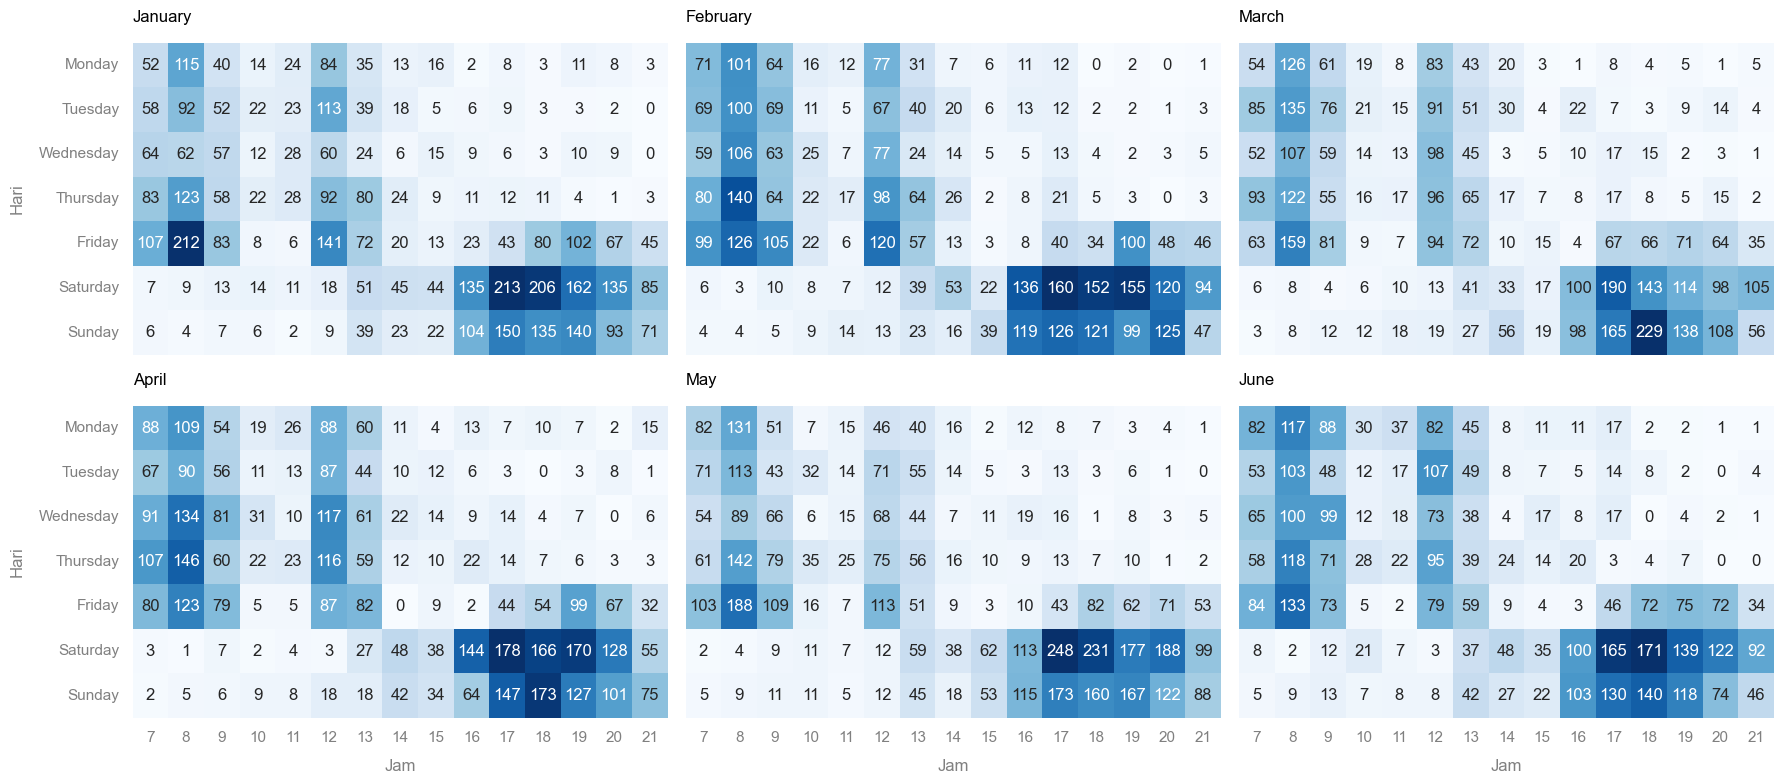

In [14]:
urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
urutan_bulan = ['January','February','March','April','May','June']

group_data = data.groupby(['month', 'day', 'hour']).agg(
    orders=('quantity', 'sum')
).reset_index()

group_data['day'] = pd.Categorical(group_data['day'], categories=urutan_hari, ordered=True)
group_data['month'] = pd.Categorical(group_data['month'], categories=urutan_bulan, ordered=True)

def draw_heatmap(*args, **kwargs):
    data_sub = kwargs.pop('data')
    # Pivot sub-data untuk bulan ini
    pivot = data_sub.pivot_table(index='day', columns='hour', values='orders', aggfunc='sum', observed=False)
    # Reindex untuk memastikan hari berurutan
    pivot = pivot.reindex(index=urutan_hari)
    sns.heatmap(pivot, cmap='Blues', annot=True, fmt='g', cbar=False, **kwargs)

g = sns.FacetGrid(group_data, col="month", col_wrap=3, height=4, aspect=1.5)
g.map_dataframe(draw_heatmap)

g.set_titles("{col_name}")
g.set_axis_labels("Jam", "Hari")
plt.tight_layout()
plt.show()

- Secara umum, pola utama di semua bulan tetap sama dan konsisten
- hari kerja (Senin–Jumat) selalu ramai di jam berangkat kantor (08.00) dan jam makan siang (12.00)
- Sedangkan akhir pekan (Sabtu–Minggu) selalu ramai dari sore hingga malam (16.00–20.00).

### Kesimpulan

Berdasarkan investigasi data transaksi POS selama 6 bulan terakhir (Januari–Juni 2026), misteri "antrean mengular panjang tetapi pendapatan stagnan dan rugi stok" akhirnya terjawab secara ilmiah melalui tiga dimensi analisis:

1. Masalah Utama Bukan Daya Beli, Melainkan "Kecilnya Ukuran Keranjang" (Basket Size)
    - Stagnansi Tren Makro: Pendapatan bulanan Aroma Jaya berada di rentang yang datar dan sempit, yaitu Rp99 Juta hingga Rp113 Juta (selisih hanya Rp14 Juta-an).
    
    - Akar Masalah Stagnansi: Nilai belanja per struk sangat konsisten dan tidak berubah signifikan, bergerak stabil di angka ~Rp43.300 hingga ~Rp44.400 (hanya selisih Rp1.100).
    
    - Perilaku Konsumen Terbukti Monoton: Berdasarkan data histogram, sebanyak 75% dari total keseluruhan transaksi pelanggan hanya membeli 1 item, dan sangat sedikit yang membeli 2 item dalam satu struk.
    
    - Kasir terlihat sangat sibuk dan antrean mengular bukan karena kedai kebanjiran omzet baru, melainkan karena staf menghabiskan waktu dan energi untuk melayani ribuan transaksi kecil yang nilainya seragam. Kedai gagal menaikkan nilai belanja per transaksi selama 6 bulan terakhir.

2. Dikotomi Hari yang Ekstrem (Pola Kerja vs Pola Lifestyle)
    - Melalui analisis mingguan, data secara konsisten membagi kalender operasional Cabang Sudirman menjadi dua kategori yang kontras di setiap bulannya:
    
    - Kelompok Normal (Senin–Kamis): Penjualan relatif rendah, hanya mencatat ~2.600 hingga ~3.300 item terjual.
    
    - Kelompok Lonjakan 2x Lipat (Jumat–Minggu): Penjualan meledak secara konsisten di angka ~5.100 hingga ~6.200 item terjual. Angka ini menyumbang di atas 50% dari total penjualan mingguan.
    
    - Menyediakan volume stok bahan baku yang sama rata antara hari kerja (Senin–Kamis) dan akhir pekan adalah kesalahan fatal manajemen yang menjadi penyebab utama pembusukan bahan baku (deadstock) dan kerugian finansial owner.

4. Fenomena Extreme Peak Hours (Penumpukan Jam Sibuk)
    - Anomali antrean panjang tervalidasi secara kronologis melalui visualisasi heatmap per jam yang polanya berulang konstan dari Januari hingga Juni
    
    - Senin – Jumat: Kepadatan terpusat pada jendela waktu yang sempit, yaitu jam berangkat kantor (07.00–09.00) dan jam makan siang (12.00–13.00).
    
    - Khusus Jumat Malam: Terjadi gelombang keramaian kedua pada pukul 17.00–21.00 (pola pulang kantor/menyambut akhir pekan).
    
    - Sabtu & Minggu: Pola bergeser total menjadi tipe hangout lifestyle, di mana kedai mulai ramai pukul 13.00 dan mencapai puncak kejenuhan tertingginya pada pukul 16.00–21.00.
    
    - Antrean panjang terjadi karena kapasitas produksi (mesin espresso, kecepatan barista, dan kasir) mengalami overload hebat hanya pada jam-jam kritis tersebut. Di luar jam itu, kedai cenderung sepi dan idle.